# Feature engineering и подбор моделей

Скачиваем файлы

In [ ]:
!wget -q --show-progress --no-check-certificate 'https://docs.google.com/uc?export=download&id=1r0mVIQfg3HYJKFIDcHwInuBPWsUBon8z' -O events.csv.gz
!wget -q --show-progress --no-check-certificate 'https://docs.google.com/uc?export=download&id=13JonFyBxaGSZJ5F_08D6tYP2uDnv8j1a' -O test.csv
!wget -q --show-progress --no-check-certificate 'https://docs.google.com/uc?export=download&id=1rwsOr06_dM4pupnO1FhOcvqWlHAM0iVe' -O train.csv
!wget -q --show-progress --no-check-certificate 'https://docs.google.com/uc?export=download&id=1DVrGiA2Nh8KvYe4os_rR2sv9ElFFgCAv' -O metric.py

events.csv.gz       100%[===================>]  11.39M  45.4MB/s    in 0.3s    
test.csv            100%[===================>] 297.28K  --.-KB/s    in 0.02s   
train.csv           100%[===================>] 693.25K  --.-KB/s    in 0.03s   
metric.py           100%[===================>]   2.37K  --.-KB/s    in 0s      


In [ ]:
import numpy as np
import pandas as pd
import random

train = pd.read_csv('/content/train.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv('/content/test.csv', parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv('/content/events.csv.gz', parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)
print('доля ботов в train:', train.target.mean().round(4))
train.head()

(11091, 5) (4909, 4) (328905, 14)
доля ботов в train: 0.0811


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


In [ ]:
random.seed(42)

## Осмотреться

Прежде чем считать агрегаты, стоит посмотреть на данные: какие типы событий бывают, что
лежит в `platform` и `user_agent`, где пропуски, всё ли уникально.

In [ ]:
print(events.event_name.value_counts(), '\n')
print(events.platform.value_counts(), '\n')
print('пропуски по колонкам:')
print(events.isna().mean().round(3))

event_name
item_view               120817
search_results_view     100402
photo_swipe              36517
favorite_add             19049
seller_page_view         17403
contact_phone_show       11316
captcha_shown             7928
login                     6267
contact_chat_open         6125
contact_message_sent      3081
Name: count, dtype: int64 

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64 

пропуски по колонкам:
cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64


## Окно наблюдения

Признаки считаем только по событиям внутри окна: `window_start_ts <= event_ts < window_end_ts`.
Это требование из условия, а не рекомендация.

In [ ]:
def events_in_window(events, meta):
    ev = events.merge(meta[['cookie_id', 'window_start_ts', 'window_end_ts']], on='cookie_id')
    return ev[(ev.event_ts >= ev.window_start_ts) & (ev.event_ts < ev.window_end_ts)]

ev_tr = events_in_window(events, train)
ev_te = events_in_window(events, test)
print(len(ev_tr), len(ev_te))

198436 89690


## Простейшие признаки

Два агрегата — сколько событий и сколько разных объявлений. Этого заведомо мало.

In [ ]:
def basic_features(ev, meta):
    g = ev.groupby('cookie_id')
    f = pd.DataFrame({
        'n_events': g.size(),
        'item_nunique': g.item_id.nunique(),
    })
    f = meta[['cookie_id']].merge(f.reset_index(), on='cookie_id', how='left')
    return f.fillna(0)

Xtr = basic_features(ev_tr, train)
Xte = basic_features(ev_te, test)
ytr = train.target.values
Xtr.head()

,cookie_id,n_events,item_nunique
0,ck_54a059eb7d3ea68b,7,4
1,ck_7e4de46eeab82974,41,19
2,ck_9320229ef6304522,36,19
3,ck_30ccd25bc1714ed9,21,10
4,ck_a77c5f05948cdeef,29,16


## Валидация

Тест лежит **позже** трейна по времени, поэтому и валидацию честно делать по времени, а не
случайным сплитом.

Метрику берём из `metric.py` — это ровно тот код, которым считает проверяющая система.
Своя реализация почти наверняка разойдётся с официальной на одинаковых `score`:
их нельзя разделять, группа равных значений отмечается целиком.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from metric import precision_at_recall   # официальная реализация, ей же считает автопроверка
from sklearn.metrics import roc_auc_score, average_precision_score

is_valid = train.window_start_ts.ge('2026-04-17').values
cols = ['n_events', 'item_nunique']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr.loc[~is_valid, cols], ytr[~is_valid])
p_va = model.predict_proba(Xtr.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr[is_valid], p_va), 4))
print('доля ботов (это уровень константы):', round(ytr[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1025
доля ботов (это уровень константы): 0.082
ROC-AUC на валидации: 0.6074
AUC-PR на валидации: 0.1746


## Создание признаков

In [ ]:
def get_time_period(hour):
    if 0 <= hour < 6:
        return 'night'
    elif 6 <= hour < 12:
        return 'morning'
    elif 12 <= hour < 18:
        return 'afternoon'
    else:
        return 'evening'

In [ ]:
def interval_entropy(x, bins=20):
    sec = x.dt.total_seconds().dropna()
    if len(sec) < 2:
        return np.nan
    hist, _ = np.histogram(sec, bins=bins)
    p = hist / hist.sum()
    p = p[p > 0]
    return -(p * np.log2(p)).sum()

In [ ]:
def create_features(ev, meta):

    ev = ev.copy()
    # Предобработка
    ev['platform'] = (
        ev['platform']
        .fillna('')
        .str.strip()
        .str.lower()
        .replace({'iphone': 'ios'})
    )

    ev = ev.sort_values(['cookie_id', 'event_ts']).reset_index(drop=True)

    # Время
    ev['event_hour'] = ev['event_ts'].dt.hour
    ev['day_part'] = ev['event_hour'].apply(get_time_period)

    # Основная группировка по cookie
    g = ev.groupby('cookie_id', sort=False)

    # EVENT FLAGS
    event_names = [
        'item_view',
        'search_results_view',
        'photo_swipe',
        'favorite_add',
        'seller_page_view',
        'contact_message_sent',
        'login',
    ]

    for event_name in event_names:
        ev[f'is_{event_name}'] = (
            ev['event_name'] == event_name
        ).astype(int)

    event_counts = (
        ev.groupby('cookie_id')[[
            'is_item_view',
            'is_search_results_view',
            'is_photo_swipe',
            'is_favorite_add',
            'is_seller_page_view',
            'is_contact_message_sent',
            'is_login',
        ]]
        .sum()
    )

    # ACTIVITY
    activity_features = pd.DataFrame(index=g.size().index)

    activity_features['n_unique_events'] = (
        g['event_name'].nunique()
    )

    activity_features['n_unique_hours'] = (
        g['event_hour'].nunique()
    )


    # EVENTS
    event_features = pd.DataFrame(index=event_counts.index)

    event_features['n_item_view'] = (
        event_counts['is_item_view']
    )

    event_features['n_search_results_view'] = (
        event_counts['is_search_results_view']
    )

    event_features['n_photo_swipe'] = (
        event_counts['is_photo_swipe']
    )

    # Безопасное отношение двух счётчиков
    def safe_ratio(num, den):
        return (
            num
            .div(den.replace(0, np.nan))
            .replace([np.inf, -np.inf], np.nan)
            .fillna(0)
        )

    event_features['search_results_view_favorite_add_ratio'] = (
        safe_ratio(
            event_counts['is_search_results_view'],
            event_counts['is_favorite_add']
        )
    )

    event_features['seller_page_view_contact_message_sent_ratio'] = (
        safe_ratio(
            event_counts['is_seller_page_view'],
            event_counts['is_contact_message_sent']
        )
    )

    event_features['item_view_favorite_add_ratio'] = (
        safe_ratio(
            event_counts['is_item_view'],
            event_counts['is_favorite_add']
        )
    )

    event_features['seller_page_view_login_ratio'] = (
        safe_ratio(
            event_counts['is_seller_page_view'],
            event_counts['is_login']
        )
    )


    # ITEMS
    item_features = pd.DataFrame(index=g.size().index)

    # Сколько событий приходится на каждый item
    events_per_item = (
        ev.groupby(['cookie_id', 'item_id'])
        .size()
    )

    item_features['n_events_per_item_mean'] = (
        events_per_item
        .groupby('cookie_id')
        .mean()
    )

    item_features['n_events_per_item_median'] = (
        events_per_item
        .groupby('cookie_id')
        .median()
    )

    # Сколько разных типов событий приходится на каждый item
    unique_events_per_item = (
        ev.groupby(['cookie_id', 'item_id'])['event_name']
        .nunique()
    )

    item_features['n_unique_events_per_item_mean'] = (
        unique_events_per_item
        .groupby('cookie_id')
        .mean()
    )

    item_features['n_unique_events_per_item_median'] = (
        unique_events_per_item
        .groupby('cookie_id')
        .median()
    )

    item_features['n_item_categories'] = (
        g['item_category'].nunique()
    )

    # GEOGRAPHY
    geography_features = pd.DataFrame(index=g.size().index)

    geography_features['n_unique_cities'] = (
        g['item_location'].nunique()
    )

    # Доля событий в самом популярном городе
    city_counts = (
        ev.groupby(['cookie_id', 'item_location'])
        .size()
    )

    city_shares = (
        city_counts
        / city_counts.groupby(level=0).transform('sum')
    )

    most_common_city_share = (
        city_shares
        .groupby(level=0)
        .max()
    )

    geography_features['most_common_city_share'] = (
        most_common_city_share
    )

    # SEARCH
    search_features = pd.DataFrame(index=g.size().index)

    search_features['n_unique_search_queries'] = (
        g['search_query'].nunique()
    )

    # Уникальные запросы внутри каждой категории
    queries_per_category = (
        ev.dropna(subset=['search_query', 'item_category'])
        .groupby(['cookie_id', 'item_category'])['search_query']
        .nunique()
    )

    search_features['n_unique_search_queries_in_category_mean'] = (
        queries_per_category
        .groupby('cookie_id')
        .mean()
    )

    search_features['n_unique_search_queries_in_category_median'] = (
        queries_per_category
        .groupby('cookie_id')
        .median()
    )

    # Длина запроса в словах
    query_words = (
        ev['search_query']
        .fillna('')
        .astype(str)
        .str.split()
        .str.len()
    )

    query_length = (
        pd.DataFrame({
            'cookie_id': ev['cookie_id'],
            'query_length': query_words
        })
        .groupby('cookie_id')['query_length']
    )

    search_features['search_query_length_mean'] = (
        query_length.mean()
    )

    search_features['search_query_length_median'] = (
        query_length.median()
    )

    search_features['search_page_mean'] = (
        g['search_page'].mean()
    )

    search_features['search_page_median'] = (
        g['search_page'].median()
    )

    # Доля повторных запросов
    search_features['duplicated_queries_ratio'] = (
        g['search_query']
        .apply(lambda s: s.dropna().duplicated().mean())
    )

    # TIMING
    ev['delta'] = (
        ev.groupby('cookie_id')['event_ts']
        .diff()
    )

    timing_features = pd.DataFrame(index=g.size().index)

    timing_features['gap_mean'] = (
        ev.groupby('cookie_id')['delta']
        .mean()
        .dt.total_seconds()
    )

    timing_features['gap_median'] = (
        ev.groupby('cookie_id')['delta']
        .median()
        .dt.total_seconds()
    )

    timing_features['gap_std'] = (
        ev.groupby('cookie_id')['delta']
        .std()
        .dt.total_seconds()
    )

    timing_features['entropy'] = (
        ev.groupby('cookie_id')['delta']
        .apply(interval_entropy)
    )

    # Максимальное количество событий в скользящем временном окне
    def max_events_in_window(group, window):
        if group.empty:
            return 0

        rolling_count = (
            group
            .set_index('event_ts')['event_name']
            .rolling(window)
            .count()
        )

        return rolling_count.max()

    max_1m = (
        ev.groupby('cookie_id', group_keys=False)
        .apply(lambda x: max_events_in_window(x, '1min'))
    )

    max_5m = (
        ev.groupby('cookie_id', group_keys=False)
        .apply(lambda x: max_events_in_window(x, '5min'))
    )

    max_30m = (
        ev.groupby('cookie_id', group_keys=False)
        .apply(lambda x: max_events_in_window(x, '30min'))
    )

    timing_features['max_events_1min'] = max_1m
    timing_features['max_events_5min'] = max_5m
    timing_features['max_events_30min'] = max_30m

    # USER-AGENT
    ua = (
        ev['user_agent']
        .fillna('')
        .str.lower()
    )

    ev['ua_headless_chrome'] = (
        ua.str.contains('headlesschrome', regex=False)
        .astype(int)
    )

    ev['ua_ios'] = (
        ua.str.contains(
            'iphone|ipad|ipod',
            regex=True
        )
        .astype(int)
    )

    ev['ua_safari'] = (
        ua.str.contains('safari', regex=False)
        &
        ~ua.str.contains('chrome', regex=False)
    ).astype(int)

    ev['ua_linux'] = (
        ua.str.contains('linux', regex=False)
        &
        ~ua.str.contains('android', regex=False)
    ).astype(int)

    ev['ua_android'] = (
        ua.str.contains('android', regex=False)
        .astype(int)
    )

    ua_features = (
        ev.groupby('cookie_id')[
            [
                'ua_headless_chrome',
                'ua_ios',
                'ua_safari',
                'ua_linux',
                'ua_android',
            ]
        ]
        .max()
    )

    # POINTER
    ev['prev_x'] = (
        ev.groupby('cookie_id')['pointer_x']
        .shift(1)
    )

    ev['prev_y'] = (
        ev.groupby('cookie_id')['pointer_y']
        .shift(1)
    )

    movement_mask = (
        ev['pointer_x'].notna()
        &
        ev['pointer_y'].notna()
        &
        ev['prev_x'].notna()
        &
        ev['prev_y'].notna()
    )

    ev['dx'] = ev['pointer_x'] - ev['prev_x']
    ev['dy'] = ev['pointer_y'] - ev['prev_y']

    ev['distance'] = np.sqrt(
        ev['dx'] ** 2 +
        ev['dy'] ** 2
    )

    movement_features = (
        ev.loc[movement_mask]
        .groupby('cookie_id')
        .agg(
            pointer_moves=('distance', 'size'),
            distance_median=('distance', 'median'),
        )
    )

    # DAY PART
    day_part_flags = (
        ev.assign(_val=1)
        .pivot_table(
            index='cookie_id',
            columns='day_part',
            values='_val',
            aggfunc='max',
            fill_value=0,
        )
    )

    activity_features = activity_features.join(
        day_part_flags
        .reindex(columns=[
            'night',
            'morning',
            'afternoon',
            'evening'
        ], fill_value=0)
        .rename(columns={
            'night': 'is_active_night',
            'morning': 'is_active_morning',
            'afternoon': 'is_active_afternoon',
            'evening': 'is_active_evening',
        })
    )

    # PLATFORM
    platform_flags = (
        ev.assign(_val=1)
        .pivot_table(
            index='cookie_id',
            columns='platform',
            values='_val',
            aggfunc='max',
            fill_value=0,
        )
    )

    platform_features = pd.DataFrame(
        index=g.size().index
    )

    for col in PLATFORM:
        platform = col.replace('platform_', '')

        if platform in platform_flags.columns:
            platform_features[col] = (
                platform_flags[platform]
                .reindex(platform_features.index)
                .fillna(0)
                .astype(int)
            )
        else:
            platform_features[col] = 0

    # EVENT TRANSITIONS
    ev['prev_event'] = (
        ev.groupby('cookie_id')['event_name']
        .shift(1)
    )

    ev['transition'] = (
        'transition_'
        + ev['prev_event'].fillna('')
        + '_'
        + ev['event_name'].fillna('')
    )

    transition_counts = (
        ev[
            ev['transition'].isin(TRANSITIONS)
        ]
        .groupby(['cookie_id', 'transition'])
        .size()
        .unstack(fill_value=0)
        .reindex(columns=TRANSITIONS, fill_value=0)
    )

    # Используем доли переходов, а не абсолютные количества, чтобы признаки меньше зависели от общего n_events.
    transition_shares = (
        transition_counts
        .div(
            transition_counts.sum(axis=1)
            .replace(0, np.nan),
            axis=0
        )
        .fillna(0)
    )

    transition_features = pd.DataFrame(
        index=g.size().index
    )

    for col in TRANSITIONS:
        transition_features[col] = (
            transition_shares[col]
            .reindex(transition_features.index)
            .fillna(0)
        )

    # СОБИРАЕМ ВСЕ БЛОКИ
    f = pd.concat(
        [
            activity_features,
            event_features,
            item_features,
            geography_features,
            search_features,
            timing_features,
            ua_features,
            movement_features,
            platform_features,
            transition_features,
        ],
        axis=1
    )

    # Возвращаем строки в том же порядке cookie_id, что и в meta
    f = (
        meta[['cookie_id']]
        .drop_duplicates()
        .set_index('cookie_id')
        .join(f)
    )

    return f

In [ ]:
BASELINE = [
    'n_events',
    'item_nunique',
]

ACTIVITY = [
    'n_unique_events',
    'n_unique_hours',
    'is_active_night',
    'is_active_morning',
    'is_active_afternoon',
    'is_active_evening',
]

EVENTS = [
    'n_item_view',
    'n_search_results_view',
    'n_photo_swipe',
    'search_results_view_favorite_add_ratio',
    'seller_page_view_contact_message_sent_ratio',
    'item_view_favorite_add_ratio',
    'seller_page_view_login_ratio',
]

ITEMS = [
    'n_events_per_item_mean',
    'n_events_per_item_median',
    'n_unique_events_per_item_mean',
    'n_unique_events_per_item_median',
    'n_item_categories',
]

GEOGRAPHY = [
    'n_unique_cities',
    'most_common_city_share',
]

SEARCH = [
    'n_unique_search_queries',
    'n_unique_search_queries_in_category_mean',
    'n_unique_search_queries_in_category_median',
    'search_query_length_mean',
    'search_query_length_median',
    'search_page_mean',
    'search_page_median',
    'duplicated_queries_ratio',
]

TIMING = [
    'gap_mean',
    'gap_median',
    'gap_std',
    'entropy',
    'max_events_1min',
    'max_events_5min',
    'max_events_30min',
]

UA = [
    'ua_android',
    'ua_ios',
    'ua_safari',
    'ua_linux',
    'ua_headless_chrome',
]

POINTER = [
    'distance_median',
    'pointer_moves',
]

PLATFORM = [
    'platform_android',
    'platform_ios',
    'platform_desktop',
]

TRANSITIONS = [
    'transition_item_view_item_view',
    'transition_item_view_search_results_view',
    'transition_search_results_view_item_view',
    'transition_search_results_view_search_results_view',
]

In [ ]:
Xtr_ultim = create_features(ev_tr, train)
Xte_ultim = create_features(ev_te, test)
ytr_ultim = train.target.values

print(Xtr.shape)
print(Xtr.columns.tolist())
print(Xtr.isna().sum().sort_values(ascending=False).head(20))
print(np.isinf(Xtr.select_dtypes(include=np.number)).sum().sum())

/tmp/ipykernel_3331/2061217669.py:299: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: max_events_in_window(x, '1min'))
/tmp/ipykernel_3331/2061217669.py:304: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: max_events_in_window(x, '5min'))
/tmp/ipykernel_3331/2061217669.py:309: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is depreca

(11091, 3)
['cookie_id', 'n_events', 'item_nunique']
cookie_id       0
n_events        0
item_nunique    0
dtype: int64
0


In [ ]:
Xtr_ultim = Xtr_ultim.merge(Xtr, on=['cookie_id'])
Xte_ultim = Xte_ultim.merge(Xte, on=['cookie_id'])

## Постепенно добавляем все группы признаков
Чтобы понять, дают ли они положительный сигнал для модели

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1407
доля ботов: 0.082
ROC-AUC на валидации: 0.7125
AUC-PR на валидации: 0.2734


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY + EVENTS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1353
доля ботов: 0.082
ROC-AUC на валидации: 0.7483
AUC-PR на валидации: 0.3452


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY + EVENTS + ITEMS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1801
доля ботов: 0.082
ROC-AUC на валидации: 0.777
AUC-PR на валидации: 0.391


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.229
доля ботов: 0.082
ROC-AUC на валидации: 0.7911
AUC-PR на валидации: 0.4197


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.2628
доля ботов: 0.082
ROC-AUC на валидации: 0.8231
AUC-PR на валидации: 0.4672


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3849
доля ботов: 0.082
ROC-AUC на валидации: 0.8631
AUC-PR на валидации: 0.6072


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3733
доля ботов: 0.082
ROC-AUC на валидации: 0.8668
AUC-PR на валидации: 0.607


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4291
доля ботов: 0.082
ROC-AUC на валидации: 0.8843
AUC-PR на валидации: 0.6409


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3993
доля ботов: 0.082
ROC-AUC на валидации: 0.8825
AUC-PR на валидации: 0.64


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4029
доля ботов: 0.082
ROC-AUC на валидации: 0.8806
AUC-PR на валидации: 0.6349


| Block         | P@R70 | delta |
| ------------- | ----: | ------------: |
| Baseline      |  0.1025 |             — |
| + Activity    |  0.1407 |         +0.0382 |
| + Events      |  0.1353 |         -0.0054 |
| + Items       |  0.1801 |         +0.0448 |
| + Geography       |   0.229 |         +0.0489 |
| + Search      |  0.2628 |         +0.0338 |
| + Timing      |  0.3849 |         +0.1221 |
| + UA          |  0.3733 |         -0.0116 |
| + Pointer     |  0.4291 |         +0.0558 |
| + Platform     |  0.3993 |         -0.0298 |
| Full          |  0.4029 |         +0.0036 |


## Ablation
Удалим признаки по одному

Нужна ли группе остальным признакам, когда уже есть всё остальное?

Все признаки для сравнения

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4029
доля ботов: 0.082
ROC-AUC на валидации: 0.8806
AUC-PR на валидации: 0.6349


Без transitions

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3993
доля ботов: 0.082
ROC-AUC на валидации: 0.8825
AUC-PR на валидации: 0.64


Без platform

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4191
доля ботов: 0.082
ROC-AUC на валидации: 0.8826
AUC-PR на валидации: 0.6357


Без pointer

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4043
доля ботов: 0.082
ROC-AUC на валидации: 0.8695
AUC-PR на валидации: 0.6108


Без UA

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4609
доля ботов: 0.082
ROC-AUC на валидации: 0.8862
AUC-PR на валидации: 0.639


Без Timing

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3146
доля ботов: 0.082
ROC-AUC на валидации: 0.8434
AUC-PR на валидации: 0.5279


Без search

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4259
доля ботов: 0.082
ROC-AUC на валидации: 0.8839
AUC-PR на валидации: 0.6305


Без geography

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4409
доля ботов: 0.082
ROC-AUC на валидации: 0.8744
AUC-PR на валидации: 0.6315


Без items

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4324
доля ботов: 0.082
ROC-AUC на валидации: 0.8791
AUC-PR на валидации: 0.6288


Без events

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.448
доля ботов: 0.082
ROC-AUC на валидации: 0.8857
AUC-PR на валидации: 0.6338


Без activity

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4275
доля ботов: 0.082
ROC-AUC на валидации: 0.8777
AUC-PR на валидации: 0.6304


| Block         | P@R70 | delta |
| ------------- | ----: | ------------: |
| Full      |  0.4029 |         - |
| - Activity    |  0.4275 |         +0.0246 |
| - Events      |  0.448 |         + 0.0451 |
| - Items       |  0.4324 |         +0.0295 |
| - Geography       |   0.4409 |         +0.038 |
| - Search      |  0.4259 |         +0.023 |
| - Timing      |  0.3146 |         -0.0883 |
| - UA          |  0.4609 |         +0.058 |
| - Pointer     |  0.4043 |         +0.0014 |
| - Platform     |  0.4191 |         +0.0162 |
| - Transitions          |  0.3993 |         -0.0036 |

## Посмотрим прирост по каждой отдельно метрике относительно байзлайна
Есть ли в группе самостоятельный сигнал относительно baseline?

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = ['n_events', 'item_nunique']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr.loc[~is_valid, cols], ytr[~is_valid])
p_va = model.predict_proba(Xtr.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr[is_valid], p_va), 4))
print('доля ботов (это уровень константы):', round(ytr[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1025
доля ботов (это уровень константы): 0.082
ROC-AUC на валидации: 0.6074
AUC-PR на валидации: 0.1746


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1407
доля ботов: 0.082
ROC-AUC на валидации: 0.7125
AUC-PR на валидации: 0.2734


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + EVENTS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1453
доля ботов: 0.082
ROC-AUC на валидации: 0.7305
AUC-PR на валидации: 0.3174


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ITEMS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1289
доля ботов: 0.082
ROC-AUC на валидации: 0.6913
AUC-PR на валидации: 0.2559


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + GEOGRAPHY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.127
доля ботов: 0.082
ROC-AUC на валидации: 0.6912
AUC-PR на валидации: 0.2402


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + SEARCH

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.139
доля ботов: 0.082
ROC-AUC на валидации: 0.7285
AUC-PR на валидации: 0.3555


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + TIMING

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3005
доля ботов: 0.082
ROC-AUC на валидации: 0.8371
AUC-PR на валидации: 0.5201


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + UA

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1068
доля ботов: 0.082
ROC-AUC на валидации: 0.6288
AUC-PR на валидации: 0.2208


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + POINTER

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1407
доля ботов: 0.082
ROC-AUC на валидации: 0.7178
AUC-PR на валидации: 0.2982


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + PLATFORM

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1143
доля ботов: 0.082
ROC-AUC на валидации: 0.6458
AUC-PR на валидации: 0.2012


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1212
доля ботов: 0.082
ROC-AUC на валидации: 0.6691
AUC-PR на валидации: 0.2182


| Block         | P@R70 | delta |
| ------------- | ----: | ------------: |
| Baseline      |  0.1025 |             — |
| BL + Activity    |  0.1407 |         +0.0382 |
| BL + Events      |  0.1453 |         + 0.0428 |
| BL + Items       |  0.1289 |         +0.0264 |
| BL + Geography       |    0.127 |         +0.0245 |
| BL + Search      |  0.139 |         +0.0365 |
| BL + Timing      |  0.3005 |         +0.198 |
| BL + UA          |  0.1068 |         +0.0043 |
| BL + Pointer     |  0.1407 |         +0.0382 |
| BL + Platform     |  0.1143 |         +0.0118 |
| BL + Transitions          |  0.1212 |         +0.0187 |

Самый большой прирост на всех проверках дает группа timning. Признаки, основанные на User-Agent, не демонстрируют заметного положительного вклада в проведённых экспериментах. При добавлении к baseline прирост составил всего +0.0043, а при удалении UA из полного набора P@R70 вырос с 0.4029 до 0.4609. Также слабый сигнал дают признаки группы Events и Platform.

## Смотрим отдельно на самый сильный признак

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + TIMING

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3005
доля ботов: 0.082
ROC-AUC на валидации: 0.8371
AUC-PR на валидации: 0.5201


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ['entropy', 'max_events_1min', 'max_events_5min', 'max_events_30min']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.2267
доля ботов: 0.082
ROC-AUC на валидации: 0.8187
AUC-PR на валидации: 0.4849


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3209
доля ботов: 0.082
ROC-AUC на валидации: 0.8402
AUC-PR на валидации: 0.5223


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ['entropy', 'gap_mean', 'gap_median', 'gap_std']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.2654
доля ботов: 0.082
ROC-AUC на валидации: 0.8179
AUC-PR на валидации: 0.4972


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ['gap_mean', 'gap_median', 'gap_std']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.2528
доля ботов: 0.082
ROC-AUC на валидации: 0.8181
AUC-PR на валидации: 0.4926


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ['entropy']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.1204
доля ботов: 0.082
ROC-AUC на валидации: 0.6688
AUC-PR на валидации: 0.2302


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ['max_events_1min', 'max_events_5min', 'max_events_30min']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.244
доля ботов: 0.082
ROC-AUC на валидации: 0.8194
AUC-PR на валидации: 0.4713


| Timing-вариант | Признаки                                |P@R0.7                                |
| -------------- | --------------------------------------- |--------------------------------------- |
| Timing full    | все 7                                   |0.3005|
| - gap          | без `gap_mean`, `gap_median`, `gap_std` |0.2267|
| - entropy      | без `entropy`                           |0.3209|
| - burst        | без `max_events_1min/5min/30min`        |0.2654|
| gaps only      | `gap_mean`, `gap_median`, `gap_std`     |0.2528|
| entropy only   | `entropy`                               |0.1204|
| burst only     | `max_events_*`                          |0.244|


## Пробуем потенциально сильное сочетание
BASELINE
+ Activity
+ Items
+ Geography
+ Search
+ Timing (['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'])
+ Pointer

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY + ITEMS + GEOGRAPHY + SEARCH + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4498
доля ботов: 0.082
ROC-AUC на валидации: 0.8885
AUC-PR на валидации: 0.6314


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4324
доля ботов: 0.082
ROC-AUC на валидации: 0.884
AUC-PR на валидации: 0.6274


Действительно без энтропии сигнал лучше

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4609
доля ботов: 0.082
ROC-AUC на валидации: 0.8862
AUC-PR на валидации: 0.639


а если убрать platform?

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4647
доля ботов: 0.082
ROC-AUC на валидации: 0.8828
AUC-PR на валидации: 0.6391


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4275
доля ботов: 0.082
ROC-AUC на валидации: 0.8867
AUC-PR на валидации: 0.6367


уберем и events

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE + ACTIVITY  + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4313
доля ботов: 0.082
ROC-AUC на валидации: 0.8844
AUC-PR на валидации: 0.6244


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE + ACTIVITY  + ITEMS + GEOGRAPHY + SEARCH + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4088
доля ботов: 0.082
ROC-AUC на валидации: 0.8875
AUC-PR на валидации: 0.6225


Убираем transitions

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3973
доля ботов: 0.082
ROC-AUC на валидации: 0.8824
AUC-PR на валидации: 0.6337


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4118
доля ботов: 0.082
ROC-AUC на валидации: 0.8902
AUC-PR на валидации: 0.643


В совокупности признаков transitions не несет положительного сигнала

Использование неполной группы признаков timing чаще всего приводило к ухудшению целевой метрики.
Лучшая целевая метрика, которой удалось добиться - 0.4647 на наборе признаков (BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER + TRANSITIONS)

## Пробуем другие сочетания


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min']

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3209
доля ботов: 0.082
ROC-AUC на валидации: 0.8402
AUC-PR на валидации: 0.5223


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + TIMING

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3005
доля ботов: 0.082
ROC-AUC на валидации: 0.8371
AUC-PR на валидации: 0.5201


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3797
доля ботов: 0.082
ROC-AUC на валидации: 0.8767
AUC-PR на валидации: 0.5925


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + TIMING + POINTER

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4043
доля ботов: 0.082
ROC-AUC на валидации: 0.8735
AUC-PR на валидации: 0.5879


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + SEARCH

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3601
доля ботов: 0.082
ROC-AUC на валидации: 0.8568
AUC-PR на валидации: 0.5705


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + TIMING + SEARCH

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3836
доля ботов: 0.082
ROC-AUC на валидации: 0.853
AUC-PR на валидации: 0.5723


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3784
доля ботов: 0.082
ROC-AUC на валидации: 0.8844
AUC-PR на валидации: 0.6151


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + TIMING + POINTER + SEARCH

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3709
доля ботов: 0.082
ROC-AUC на валидации: 0.8771
AUC-PR на валидации: 0.6162


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH + ITEMS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4462
доля ботов: 0.082
ROC-AUC на валидации: 0.8846
AUC-PR на валидации: 0.6223


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + TIMING + POINTER + SEARCH + ITEMS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4211
доля ботов: 0.082
ROC-AUC на валидации: 0.8801
AUC-PR на валидации: 0.6235


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH + ITEMS + ACTIVITY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.3958
доля ботов: 0.082
ROC-AUC на валидации: 0.8813
AUC-PR на валидации: 0.6262


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + TIMING + POINTER + SEARCH + ITEMS + ACTIVITY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.427
доля ботов: 0.082
ROC-AUC на валидации: 0.8829
AUC-PR на валидации: 0.6205


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH + ITEMS + ACTIVITY + GEOGRAPHY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4427
доля ботов: 0.082
ROC-AUC на валидации: 0.8912
AUC-PR на валидации: 0.6341


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH + ITEMS + GEOGRAPHY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4226
доля ботов: 0.082
ROC-AUC на валидации: 0.891
AUC-PR на валидации: 0.6342


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + TIMING + POINTER + SEARCH + ITEMS + ACTIVITY + GEOGRAPHY

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4291
доля ботов: 0.082
ROC-AUC на валидации: 0.8867
AUC-PR на валидации: 0.6256


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH + ITEMS + ACTIVITY + GEOGRAPHY + EVENTS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4103
доля ботов: 0.082
ROC-AUC на валидации: 0.8887
AUC-PR на валидации: 0.6349


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + TIMING + POINTER + SEARCH + ITEMS + ACTIVITY + GEOGRAPHY + EVENTS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4088
доля ботов: 0.082
ROC-AUC на валидации: 0.8778
AUC-PR на валидации: 0.6313


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH + ITEMS + GEOGRAPHY + EVENTS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4
доля ботов: 0.082
ROC-AUC на валидации: 0.887
AUC-PR на валидации: 0.6395


Явного прироста в сравнении с лучшей целевой метрикой чисто сильные признаки из timing не дают

# Перейдем к сравнению моделей
Так как последовательный перебор признаков больше не дает явного прироста, сравним следующие модели с полным набором признаков и с найденной лучшей для байзлайна комбинацией: байзлайн (RF), LightGBM, XGBoost

In [ ]:
import lightgbm as lgb
import xgboost as xgb
from sklearn.metrics import roc_auc_score, average_precision_score
from metric import precision_at_recall
from sklearn.ensemble import RandomForestClassifier

## Baseline

In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4029
доля ботов: 0.082
ROC-AUC на валидации: 0.8806
AUC-PR на валидации: 0.6349


In [ ]:
is_valid = train.window_start_ts.ge('2026-04-17').values
cols =  BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER + TRANSITIONS

model = RandomForestClassifier(n_estimators=300, min_samples_leaf=3, random_state=0)
model.fit(Xtr_ultim.loc[~is_valid, cols], ytr_ultim[~is_valid])
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]
print('P@R0.7 на валидации:', round(precision_at_recall(ytr_ultim[is_valid], p_va), 4))
print('доля ботов:', round(ytr_ultim[is_valid].mean(), 4))
print('ROC-AUC на валидации:', round(roc_auc_score(ytr_ultim[is_valid], p_va), 4))
print('AUC-PR на валидации:', round(average_precision_score(ytr_ultim[is_valid], p_va), 4))

P@R0.7 на валидации: 0.4647
доля ботов: 0.082
ROC-AUC на валидации: 0.8828
AUC-PR на валидации: 0.6391


## LightGBM

In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=0,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

p_va_lgb = lgb_model.predict_proba(X_valid)[:, 1]

print('LightGBM')
print('P@R0.7:', precision_at_recall(y_valid, p_va_lgb))
print('ROC-AUC:', roc_auc_score(y_valid, p_va_lgb))
print('AUC-PR:', average_precision_score(y_valid, p_va_lgb))

LightGBM
P@R0.7: 0.45901639344262296
ROC-AUC: 0.8832443467336684
AUC-PR: 0.6536973774087591


In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=0,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

p_va_lgb = lgb_model.predict_proba(X_valid)[:, 1]

print('LightGBM')
print('P@R0.7:', precision_at_recall(y_valid, p_va_lgb))
print('ROC-AUC:', roc_auc_score(y_valid, p_va_lgb))
print('AUC-PR:', average_precision_score(y_valid, p_va_lgb))

LightGBM
P@R0.7: 0.4148148148148148
ROC-AUC: 0.885198562255723
AUC-PR: 0.6506271497907172


In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=0,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

p_va_lgb = lgb_model.predict_proba(X_valid)[:, 1]

print('LightGBM')
print('P@R0.7:', precision_at_recall(y_valid, p_va_lgb))
print('ROC-AUC:', roc_auc_score(y_valid, p_va_lgb))
print('AUC-PR:', average_precision_score(y_valid, p_va_lgb))

LightGBM
P@R0.7: 0.4375
ROC-AUC: 0.8865490647682859
AUC-PR: 0.6422557278123312


In [ ]:
cols = BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH + ITEMS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

lgb_model = lgb.LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    random_state=0,
    verbosity=-1
)

lgb_model.fit(
    X_train,
    y_train
)

p_va_lgb = lgb_model.predict_proba(X_valid)[:, 1]

print('LightGBM')
print('P@R0.7:', precision_at_recall(y_valid, p_va_lgb))
print('ROC-AUC:', roc_auc_score(y_valid, p_va_lgb))
print('AUC-PR:', average_precision_score(y_valid, p_va_lgb))

LightGBM
P@R0.7: 0.3875432525951557
ROC-AUC: 0.8703482691233947
AUC-PR: 0.6251697626768057


## XGBoost

In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

p_va_xgb = xgb_model.predict_proba(X_valid)[:, 1]

print('XGBoost')
print('P@R0.7:', precision_at_recall(y_valid, p_va_xgb))
print('ROC-AUC:', roc_auc_score(y_valid, p_va_xgb))
print('AUC-PR:', average_precision_score(y_valid, p_va_xgb))

XGBoost
P@R0.7: 0.48068669527896996
ROC-AUC: 0.8899968592964824
AUC-PR: 0.6664047671204018


In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + POINTER + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

p_va_xgb = xgb_model.predict_proba(X_valid)[:, 1]

print('XGBoost')
print('P@R0.7:', precision_at_recall(y_valid, p_va_xgb))
print('ROC-AUC:', roc_auc_score(y_valid, p_va_xgb))
print('AUC-PR:', average_precision_score(y_valid, p_va_xgb))

XGBoost
P@R0.7: 0.4765957446808511
ROC-AUC: 0.8876308626465661
AUC-PR: 0.6497049843295062


In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

p_va_xgb = xgb_model.predict_proba(X_valid)[:, 1]

print('XGBoost')
print('P@R0.7:', precision_at_recall(y_valid, p_va_xgb))
print('ROC-AUC:', roc_auc_score(y_valid, p_va_xgb))
print('AUC-PR:', average_precision_score(y_valid, p_va_xgb))

XGBoost
P@R0.7: 0.4307692307692308
ROC-AUC: 0.8895135399218315
AUC-PR: 0.6509183481599573


In [ ]:
cols = BASELINE  + ['gap_mean', 'gap_median', 'gap_std' ,'max_events_1min', 'max_events_5min', 'max_events_30min'] + POINTER + SEARCH + ITEMS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    eval_metric='logloss'
)

xgb_model.fit(
    X_train,
    y_train
)

p_va_xgb = xgb_model.predict_proba(X_valid)[:, 1]

print('XGBoost')
print('P@R0.7:', precision_at_recall(y_valid, p_va_xgb))
print('ROC-AUC:', roc_auc_score(y_valid, p_va_xgb))
print('AUC-PR:', average_precision_score(y_valid, p_va_xgb))

XGBoost
P@R0.7: 0.40213523131672596
ROC-AUC: 0.8860971524288107
AUC-PR: 0.6369769108012341


| Model    | Features | P@R70 | ROC-AUC | AUC-PR |
| -------- | -------- | ----: | ------: | -----: |
| RF       | Full     |   0.4029    |    0.8806     |   0.6349     |
| RF       | Best     | 0.4647 |    0.8828     |   0.6391      |
| LightGBM  | Full     |   0.459    |    0.8832     |   0.6536     |
| LightGBM  | Best     |   0.4148 (если убрать энтропию 0.4375)   |     0.8851 (0.8865)    |   0.65062 (0.6422)    |
| XGBoost | Full     |    0.4806   |   0.8899      |    0.6664    |
| XGBoost | Best     |   0.4765    |    0.8876     |     0.6497   |



Лучшие результаты показал XGBoost на полном сформированном наборе признаков

## Подбираем гиперпараметры XGBoost

Далее фиксируем набор признаков, сплит и меняем только гиперпараметры для улучшения результата

Проверим на более простых деревьях, более сложных, посмотрим, насколько легко модели создавать новые листья, а также увеличим количество деревьев в рамках разных экспериментов.

In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]



experiments = [
    # max_depth = 4
    {'max_depth': 4, 'min_child_weight': 1, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 4, 'min_child_weight': 3, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 4, 'min_child_weight': 5, 'learning_rate': 0.05, 'n_estimators': 300},

    # max_depth = 6
    {'max_depth': 6, 'min_child_weight': 1, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 6, 'min_child_weight': 3, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 6, 'min_child_weight': 5, 'learning_rate': 0.05, 'n_estimators': 300},

    # max_depth = 8
    {'max_depth': 8, 'min_child_weight': 1, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 8, 'min_child_weight': 3, 'learning_rate': 0.05, 'n_estimators': 300},
    {'max_depth': 8, 'min_child_weight': 5, 'learning_rate': 0.05, 'n_estimators': 300},

    # больше деревьев + меньший learning rate
    {'max_depth': 6, 'min_child_weight': 3, 'learning_rate': 0.03, 'n_estimators': 500},
    {'max_depth': 6, 'min_child_weight': 3, 'learning_rate': 0.02, 'n_estimators': 700},
]


results = []

for params in experiments:
    model = xgb.XGBClassifier(
        **params,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=0,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train, y_train)

    p_va = model.predict_proba(X_valid)[:, 1]

    results.append({
        **params,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })


results_df = pd.DataFrame(results)
results_df.sort_values('P@R70', ascending=False)

,max_depth,min_child_weight,learning_rate,n_estimators,P@R70,ROC-AUC,AUC-PR
10,6,3,0.02,700,0.513636,0.895650,0.667709
0,4,1,0.05,300,0.509091,0.897713,0.667221
2,4,5,0.05,300,0.497778,0.896994,0.657241
7,8,3,0.05,300,0.489083,0.890587,0.661234
1,4,3,0.05,300,0.481172,0.895001,0.662955
3,6,1,0.05,300,0.480687,0.889997,0.666405
9,6,3,0.03,500,0.466667,0.893989,0.665477
4,6,3,0.05,300,0.459016,0.891773,0.661238
8,8,5,0.05,300,0.457143,0.893186,0.660653
6,8,1,0.05,300,0.448000,0.891951,0.667730


`max_depth=6, min_child_weight=3, learning_rate=0.02, n_estimators=700` - пока лучший вариант по целевой метрике.

Снижение lr и увеличение числа деревьев стоит исследовать дальше.

In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]


# зафиксируем все, кроме lr и кол-ва деревьев
experiments = [
    {'learning_rate': 0.01, 'n_estimators': 1000},
    {'learning_rate': 0.015, 'n_estimators': 800},
    {'learning_rate': 0.02, 'n_estimators': 500},
    {'learning_rate': 0.02, 'n_estimators': 700},
    {'learning_rate': 0.02, 'n_estimators': 900},
    {'learning_rate': 0.03, 'n_estimators': 500},
    {'learning_rate': 0.03, 'n_estimators': 700},
    {'learning_rate': 0.04, 'n_estimators': 500},
    {'learning_rate': 0.05, 'n_estimators': 300},
    {'learning_rate': 0.05, 'n_estimators': 500},
]


results = []

for params in experiments:
    model = xgb.XGBClassifier(
    max_depth=6,
    min_child_weight=3,
    learning_rate=params['learning_rate'],
    n_estimators=params['n_estimators'],
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    eval_metric='logloss',
    n_jobs=-1
    )

    model.fit(X_train, y_train)

    p_va = model.predict_proba(X_valid)[:, 1]

    results.append({
        **params,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })


results_df = pd.DataFrame(results)
results_df.sort_values('P@R70', ascending=False)

,learning_rate,n_estimators,P@R70,ROC-AUC,AUC-PR
4,0.020,900,0.518519,0.893525,0.664857
3,0.020,700,0.513636,0.895650,0.667709
2,0.020,500,0.489083,0.897587,0.668508
6,0.030,700,0.480687,0.890615,0.664275
0,0.010,1000,0.472574,0.892202,0.666565
7,0.040,500,0.468619,0.891836,0.663457
5,0.030,500,0.466667,0.893989,0.665477
1,0.015,800,0.459016,0.892220,0.666049
8,0.050,300,0.459016,0.891773,0.661238
9,0.050,500,0.430769,0.889508,0.658852


В целом увеличение числа деревьев и уменьшение скорости обучения повышают целевую метрику

In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]


experiments = [
    {'learning_rate': 0.0175, 'n_estimators': 700},
    {'learning_rate': 0.0175, 'n_estimators': 800},
    {'learning_rate': 0.0175, 'n_estimators': 900},

    {'learning_rate': 0.020, 'n_estimators': 700},
    {'learning_rate': 0.020, 'n_estimators': 800},
    {'learning_rate': 0.020, 'n_estimators': 900},
    {'learning_rate': 0.020, 'n_estimators': 1000},

    {'learning_rate': 0.0225, 'n_estimators': 700},
    {'learning_rate': 0.0225, 'n_estimators': 800},
    {'learning_rate': 0.0225, 'n_estimators': 900},

    {'learning_rate': 0.025, 'n_estimators': 600},
    {'learning_rate': 0.025, 'n_estimators': 700},
    {'learning_rate': 0.025, 'n_estimators': 800},
]

results = []

for params in experiments:
    model = xgb.XGBClassifier(
    max_depth=6,
    min_child_weight=3,
    learning_rate=params['learning_rate'],
    n_estimators=params['n_estimators'],
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    eval_metric='logloss',
    n_jobs=-1
    )

    model.fit(X_train, y_train)

    p_va = model.predict_proba(X_valid)[:, 1]

    results.append({
        **params,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })


results_df = pd.DataFrame(results)
results_df.sort_values('P@R70', ascending=False)

,learning_rate,n_estimators,P@R70,ROC-AUC,AUC-PR
10,0.0250,600,0.533333,0.893298,0.666368
7,0.0225,700,0.523364,0.893637,0.667362
9,0.0225,900,0.523364,0.892419,0.668164
5,0.0200,900,0.518519,0.893525,0.664857
4,0.0200,800,0.516129,0.894582,0.665778
11,0.0250,700,0.513636,0.892761,0.667152
3,0.0200,700,0.513636,0.895650,0.667709
6,0.0200,1000,0.511416,0.892963,0.664363
8,0.0225,800,0.509091,0.892953,0.667351
2,0.0175,900,0.506787,0.891825,0.668940


Может удастся подобраться еще ближе к минимуму, попробуем уточнить параметры.

In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

X_train = Xtr_ultim.loc[~is_valid, cols]
y_train = ytr_ultim[~is_valid]

X_valid = Xtr_ultim.loc[is_valid, cols]
y_valid = ytr_ultim[is_valid]

experiments = [
    {'learning_rate': 0.023, 'n_estimators': 500},
    {'learning_rate': 0.023, 'n_estimators': 550},
    {'learning_rate': 0.023, 'n_estimators': 600},
    {'learning_rate': 0.023, 'n_estimators': 650},

    {'learning_rate': 0.024, 'n_estimators': 500},
    {'learning_rate': 0.024, 'n_estimators': 550},
    {'learning_rate': 0.024, 'n_estimators': 600},
    {'learning_rate': 0.024, 'n_estimators': 650},

    {'learning_rate': 0.025, 'n_estimators': 500},
    {'learning_rate': 0.025, 'n_estimators': 550},
    {'learning_rate': 0.025, 'n_estimators': 600},
    {'learning_rate': 0.025, 'n_estimators': 650},

    {'learning_rate': 0.026, 'n_estimators': 500},
    {'learning_rate': 0.026, 'n_estimators': 550},
    {'learning_rate': 0.026, 'n_estimators': 600},
    {'learning_rate': 0.026, 'n_estimators': 650},
]


results = []

for params in experiments:
    model = xgb.XGBClassifier(
    max_depth=6,
    min_child_weight=3,
    learning_rate=params['learning_rate'],
    n_estimators=params['n_estimators'],
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=0,
    eval_metric='logloss',
    n_jobs=-1
    )

    model.fit(X_train, y_train)

    p_va = model.predict_proba(X_valid)[:, 1]

    results.append({
        **params,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })


results_df = pd.DataFrame(results)
results_df.sort_values('P@R70', ascending=False)

,learning_rate,n_estimators,P@R70,ROC-AUC,AUC-PR
10,0.025,600,0.533333,0.893298,0.666368
11,0.025,650,0.525822,0.892680,0.665540
8,0.025,500,0.518519,0.893958,0.666417
9,0.025,550,0.516129,0.894209,0.666770
5,0.024,550,0.513761,0.894677,0.668094
2,0.023,600,0.506787,0.893567,0.666820
6,0.024,600,0.504505,0.893630,0.666493
3,0.023,650,0.502242,0.893068,0.666106
7,0.024,650,0.502242,0.893647,0.666258
12,0.026,500,0.491228,0.891874,0.661185


Лучший результат по целевой метрике (0.533) все еще дает lr=0.025 и n_estimators = 600, зафиксируем их.

In [ ]:
subsample_values = [0.7, 0.8, 1.0]
colsample_values = [0.7, 0.8, 1.0]

experiments = [
    (s, c)
    for s in subsample_values
    for c in colsample_values
]

results = []

for subsample, colsample_bytree in experiments:
    model = xgb.XGBClassifier(
        max_depth=6,
        min_child_weight=3,
        learning_rate=0.025,
        n_estimators=600,

        subsample=subsample,
        colsample_bytree=colsample_bytree,

        random_state=0,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    p_va = model.predict_proba(X_valid)[:, 1]

    results.append({
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

subsample_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

subsample_results

,subsample,colsample_bytree,P@R70,ROC-AUC,AUC-PR
4,0.8,0.8,0.533333,0.893298,0.666368
3,0.8,0.7,0.482759,0.892461,0.668042
2,0.7,1.0,0.480687,0.896044,0.665563
5,0.8,1.0,0.470588,0.891989,0.662118
0,0.7,0.7,0.457490,0.892502,0.665603
1,0.7,0.8,0.452000,0.892872,0.669257
6,1.0,0.7,0.408759,0.889519,0.658679
8,1.0,1.0,0.402878,0.887223,0.651542
7,1.0,0.8,0.374172,0.888472,0.651876


Очевидного прироста к качеству модели subsample и colsample_bytree не дали, зафиксируем их обоих на значении 0.8. Перейдем к параметрам регуляризации.

In [ ]:
experiments = [
    (alpha, reg_lambda)
    for alpha in [0, 0.1, 1, 5]
    for reg_lambda in [1, 5, 10]
]

results = []

for reg_alpha, reg_lambda in experiments:
    model = xgb.XGBClassifier(
        max_depth=6,
        min_child_weight=3,
        learning_rate=0.025,
        n_estimators=600,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,

        random_state=0,
        eval_metric='logloss',
        n_jobs=-1
    )

    model.fit(X_train, y_train)
    p_va = model.predict_proba(X_valid)[:, 1]

    results.append({
        'reg_alpha': reg_alpha,
        'reg_lambda': reg_lambda,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

regularization_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

regularization_results

,reg_alpha,reg_lambda,P@R70,ROC-AUC,AUC-PR
0,0.0,1,0.533333,0.893298,0.666368
1,0.0,5,0.509091,0.894628,0.668397
10,5.0,5,0.500000,0.892066,0.661579
3,0.1,1,0.491228,0.893298,0.666707
8,1.0,10,0.491228,0.892988,0.663484
7,1.0,5,0.491228,0.894415,0.665611
11,5.0,10,0.491228,0.891012,0.655812
9,5.0,1,0.489083,0.893661,0.665636
4,0.1,5,0.480687,0.892014,0.663122
5,0.1,10,0.476596,0.894027,0.665051


Очевидного прироста к качеству модели reg_alpha, reg_lambda не дали, зафиксируем их обоих на значениях 0 и 1.

Лучший вариант XGBoost:

max_depth=6

min_child_weight=3

learning_rate=0.025

n_estimators=600

subsample=0.8

colsample_bytree=0.8

reg_alpha=0

reg_lambda=1

Попробуем улучшить результат с помощьюе блендинга с LightGBM

## Подбираем гиперпараметры для LightGBM

In [ ]:
num_leaves = [15, 31, 63]
max_depth = [-1, 6, 10]
min_child_samples = [20]

experiments = [
    (s, c)
    for s in num_leaves
    for c in max_depth
]

results = []

for num_leaves, max_depth in experiments:

    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=0,
        verbosity=-1,

        min_child_samples = 20,
        num_leaves=num_leaves,
        max_depth = max_depth,
    )

    lgb_model.fit( X_train,y_train)

    p_va = lgb_model.predict_proba(X_valid)[:, 1]

    results.append({
        'num_leaves': num_leaves,
        'max_depth': max_depth,
        'min_child_samples': 20,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

df_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

df_results

,num_leaves,max_depth,min_child_samples,P@R70,ROC-AUC,AUC-PR
5,31,10,20,0.486957,0.885753,0.658297
0,15,-1,20,0.484848,0.887038,0.652087
6,63,-1,20,0.480687,0.885167,0.656197
3,31,-1,20,0.459016,0.883244,0.653697
8,63,10,20,0.428571,0.881178,0.649557
2,15,10,20,0.424242,0.887296,0.657210
4,31,6,20,0.422642,0.882466,0.651982
1,15,6,20,0.421053,0.883042,0.656198
7,63,6,20,0.408759,0.879427,0.654010


In [ ]:
num_leaves = [24, 28, 31, 36, 40, 48]
max_depth = [8, 9, 10, 11, 12, -1]

experiments = [
    (s, c)
    for s in num_leaves
    for c in max_depth
]

results = []

for num_leaves, max_depth in experiments:

    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=0,
        verbosity=-1,

        min_child_samples = 20,
        num_leaves=num_leaves,
        max_depth = max_depth,
    )

    lgb_model.fit( X_train,y_train)

    p_va = lgb_model.predict_proba(X_valid)[:, 1]

    results.append({
        'num_leaves': num_leaves,
        'max_depth': max_depth,
        'min_child_samples': 20,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

df_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

df_results

,num_leaves,max_depth,min_child_samples,P@R70,ROC-AUC,AUC-PR
23,36,-1,20,0.493392,0.882344,0.653853
11,28,-1,20,0.486957,0.886204,0.653396
14,31,10,20,0.486957,0.885753,0.658297
1,24,9,20,0.460905,0.883544,0.661123
17,31,-1,20,0.459016,0.883244,0.653697
15,31,11,20,0.457143,0.885656,0.658304
3,24,11,20,0.453441,0.887718,0.658807
16,31,12,20,0.448000,0.887851,0.658195
22,36,12,20,0.448000,0.883464,0.656258
2,24,10,20,0.446215,0.886992,0.664819


остановимся на значениий num_leaves = 31, max_depth =	10

In [ ]:
min_child_sampl = [5, 10, 20, 30, 50, 80]
results = []

for  min_child_samples in min_child_sampl:

    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=0,
        verbosity=-1,
        num_leaves=31,
        max_depth = 10,

        min_child_samples = min_child_samples,
    )

    lgb_model.fit( X_train,y_train)

    p_va = lgb_model.predict_proba(X_valid)[:, 1]

    results.append({
        'min_child_samples': min_child_samples,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

df_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

df_results

,min_child_samples,P@R70,ROC-AUC,AUC-PR
2,20,0.486957,0.885753,0.658297
0,5,0.474576,0.886685,0.657377
4,50,0.460905,0.883541,0.647263
3,30,0.448000,0.885694,0.652482
5,80,0.432432,0.877008,0.644243
1,10,0.429119,0.881496,0.648627


In [ ]:
min_child_sampl = [15, 20, 25]
results = []

for  min_child_samples in min_child_sampl:

    lgb_model = lgb.LGBMClassifier(
        n_estimators=300,
        learning_rate=0.05,
        random_state=0,
        verbosity=-1,
        num_leaves=31,
        max_depth = 10,

        min_child_samples = min_child_samples,
    )

    lgb_model.fit( X_train,y_train)

    p_va = lgb_model.predict_proba(X_valid)[:, 1]

    results.append({
        'min_child_samples': min_child_samples,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

df_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

df_results

,min_child_samples,P@R70,ROC-AUC,AUC-PR
2,25,0.489083,0.884166,0.652743
1,20,0.486957,0.885753,0.658297
0,15,0.401434,0.883764,0.657286


Зафиксируем значение min_child_samples = 25

In [ ]:
learning_rate = [0.01, 0.02, 0.05]
n_estimators = [300, 600, 900]

experiments = [
    (s, c)
    for s in learning_rate
    for c in n_estimators
]

results = []

for learning_rate, n_estimators in experiments:

    lgb_model = lgb.LGBMClassifier(
        random_state=0,
        verbosity=-1,
        num_leaves=31,
        max_depth = 10,
        min_child_samples = 25,

        n_estimators=n_estimators,
        learning_rate=learning_rate,

    )

    lgb_model.fit( X_train,y_train)

    p_va = lgb_model.predict_proba(X_valid)[:, 1]

    results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

df_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

df_results

,n_estimators,learning_rate,P@R70,ROC-AUC,AUC-PR
8,900,0.05,0.495575,0.875780,0.649328
6,300,0.05,0.489083,0.884166,0.652743
0,300,0.01,0.436293,0.882295,0.642520
1,600,0.01,0.435798,0.881182,0.649651
7,600,0.05,0.432432,0.880125,0.649492
2,900,0.01,0.430769,0.883712,0.653005
5,900,0.02,0.428030,0.883304,0.649987
4,600,0.02,0.425856,0.882979,0.653168
3,300,0.02,0.400000,0.886040,0.651139


In [ ]:
learning_rate = [0.04, 0.05, 0.06]
n_estimators = [700, 900, 1100]

experiments = [
    (s, c)
    for s in learning_rate
    for c in n_estimators
]

results = []

for learning_rate, n_estimators in experiments:

    lgb_model = lgb.LGBMClassifier(
        random_state=0,
        verbosity=-1,
        num_leaves=31,
        max_depth = 10,
        min_child_samples = 25,

        n_estimators=n_estimators,
        learning_rate=learning_rate,

    )

    lgb_model.fit( X_train,y_train)

    p_va = lgb_model.predict_proba(X_valid)[:, 1]

    results.append({
        'n_estimators': n_estimators,
        'learning_rate': learning_rate,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

df_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

df_results

,n_estimators,learning_rate,P@R70,ROC-AUC,AUC-PR
4,900,0.05,0.495575,0.875780,0.649328
5,1100,0.05,0.474790,0.876279,0.648901
3,700,0.05,0.457143,0.877699,0.648575
7,900,0.06,0.453441,0.871495,0.648256
1,900,0.04,0.449799,0.878952,0.651548
2,1100,0.04,0.448000,0.875776,0.652664
8,1100,0.06,0.442688,0.871030,0.649751
6,700,0.06,0.430769,0.872608,0.647392
0,700,0.04,0.422642,0.876837,0.647031


Зафиксируем лучший результат

In [ ]:
subsample = [0.7, 0.8, 1.0]
colsample_bytree = [0.7, 0.8, 1.0]

experiments = [
    (s, c)
    for s in subsample
    for c in colsample_bytree
]

results = []

for subsample, colsample_bytree in experiments:

    lgb_model = lgb.LGBMClassifier(
        random_state=0,
        verbosity=-1,
        num_leaves=31,
        max_depth = 10,
        min_child_samples = 25,
        n_estimators=900,
        learning_rate=0.05,

        subsample=subsample,
        colsample_bytree=colsample_bytree,


    )

    lgb_model.fit( X_train,y_train)

    p_va = lgb_model.predict_proba(X_valid)[:, 1]

    results.append({
        'subsample': subsample,
        'colsample_bytree': colsample_bytree,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

df_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

df_results

,subsample,colsample_bytree,P@R70,ROC-AUC,AUC-PR
2,0.7,1.0,0.495575,0.875780,0.649328
8,1.0,1.0,0.495575,0.875780,0.649328
5,0.8,1.0,0.495575,0.875780,0.649328
0,0.7,0.7,0.484848,0.882508,0.656304
3,0.8,0.7,0.484848,0.882508,0.656304
6,1.0,0.7,0.484848,0.882508,0.656304
1,0.7,0.8,0.407942,0.874921,0.653335
4,0.8,0.8,0.407942,0.874921,0.653335
7,1.0,0.8,0.407942,0.874921,0.653335


In [ ]:

experiments = [
    (alpha, reg_lambda)
    for alpha in [0.0, 0.1, 1.0]
    for reg_lambda in [0.0, 1.0, 5.0]
]

results = []

for reg_alpha, reg_lambda in experiments:
    lgb_model = lgb.LGBMClassifier(
        random_state=0,
        verbosity=-1,
        num_leaves=31,
        max_depth = 10,
        min_child_samples = 25,
        n_estimators=900,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=1,

        reg_alpha=reg_alpha,
        reg_lambda=reg_lambda,

    )

    lgb_model.fit( X_train,y_train)

    p_va = lgb_model.predict_proba(X_valid)[:, 1]


    results.append({
        'reg_alpha': reg_alpha,
        'reg_lambda': reg_lambda,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

regularization_results = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
)

In [ ]:
regularization_results

,reg_alpha,reg_lambda,P@R70,ROC-AUC,AUC-PR
0,0.0,0.0,0.491228,0.891012,0.655812
1,0.0,1.0,0.491228,0.891012,0.655812
2,0.0,5.0,0.491228,0.891012,0.655812
3,0.1,0.0,0.491228,0.891012,0.655812
4,0.1,1.0,0.491228,0.891012,0.655812
5,0.1,5.0,0.491228,0.891012,0.655812
6,1.0,0.0,0.491228,0.891012,0.655812
7,1.0,1.0,0.491228,0.891012,0.655812
8,1.0,5.0,0.491228,0.891012,0.655812


Лучший вариант LightGBM:

        random_state=0,
        verbosity=-1,
        num_leaves=31,
        max_depth = 10,
        min_child_samples = 25,
        n_estimators=900,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=1,
        reg_alpha=0,
        reg_lambda=0

Обучим лучшие модели и попробуем их

# Блендинг

Т.к. модели используют разные принципы построения деревевьев, возможно, блендинг моделей, даст хороший прирост к целевой метрике, т.к. модели будут править ошибки друг друга

In [ ]:
best_lgb_model = lgb.LGBMClassifier(
        random_state=0,
        verbosity=-1,
        num_leaves=31,
        max_depth = 10,
        min_child_samples = 25,
        n_estimators=900,
        learning_rate=0.05,
        subsample=0.7,
        colsample_bytree=1,
        reg_alpha=0,
        reg_lambda=0

    )

best_lgb_model.fit( X_train,y_train)
p_va_lgb = best_lgb_model.predict_proba(X_valid)[:, 1]

best_xgb_model = xgb.XGBClassifier(
        max_depth=6,
        min_child_weight=3,
        learning_rate=0.025,
        n_estimators=600,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=0,
        reg_lambda=1,

        random_state=0,
        eval_metric='logloss',
        n_jobs=-1
    )

best_xgb_model.fit(X_train, y_train)
p_va_xgb = best_xgb_model.predict_proba(X_valid)[:, 1]

In [ ]:
blend_results = []

for w in np.arange(0, 1.01, 0.1):
    p_blend = w * p_va_xgb + (1 - w) * p_va_lgb

    blend_results.append({
        'xgb_weight': round(w, 2),
        'lgb_weight': round(1 - w, 2),
        'P@R70': precision_at_recall(y_valid, p_blend),
        'ROC-AUC': roc_auc_score(y_valid, p_blend),
        'AUC-PR': average_precision_score(y_valid, p_blend)
    })

blend_results = (
    pd.DataFrame(blend_results)
    .sort_values('P@R70', ascending=False)
    .reset_index(drop=True)
)

blend_results

,xgb_weight,lgb_weight,P@R70,ROC-AUC,AUC-PR
0,1.0,0.0,0.533333,0.893298,0.666368
1,0.9,0.1,0.530806,0.893218,0.667551
2,0.8,0.2,0.528302,0.893075,0.667208
3,0.7,0.3,0.523364,0.893005,0.667396
4,0.6,0.4,0.520930,0.892830,0.666911
5,0.5,0.5,0.506787,0.892569,0.666322
6,0.0,1.0,0.495575,0.875780,0.649328
7,0.1,0.9,0.495575,0.889770,0.661000
8,0.4,0.6,0.493392,0.892255,0.664928
9,0.3,0.7,0.482759,0.891972,0.665637


Блендинг не дал ожидаемого прироста, получается что XGBoost и так хорошо улавливает все зависимости, без помощи LightGBM.

# Попытки дожать XGBoost

In [ ]:
experiments = [
    (depth, child_weight)
    for depth in [5, 6, 7]
    for child_weight in [2, 3, 4, 5]
]

results = []

for max_depth, min_child_weight in experiments:

    xgb_model = xgb.XGBClassifier(
        n_estimators=600,
        learning_rate=0.025,

        max_depth=max_depth,
        min_child_weight=min_child_weight,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=0,
        reg_lambda=1,

        random_state=0,
        eval_metric='logloss',
        n_jobs=-1
    )

    xgb_model.fit(X_train, y_train)

    p_va = xgb_model.predict_proba(X_valid)[:, 1]

    results.append({
        'max_depth': max_depth,
        'min_child_weight': min_child_weight,
        'P@R70': precision_at_recall(y_valid, p_va),
        'ROC-AUC': roc_auc_score(y_valid, p_va),
        'AUC-PR': average_precision_score(y_valid, p_va)
    })

df_depth = (
    pd.DataFrame(results)
    .sort_values('P@R70', ascending=False)
    .reset_index(drop=True)
)

df_depth

,max_depth,min_child_weight,P@R70,ROC-AUC,AUC-PR
0,6,3,0.533333,0.893298,0.666368
1,6,4,0.525822,0.896543,0.667113
2,6,2,0.509091,0.894924,0.665201
3,5,3,0.495575,0.893078,0.662268
4,7,2,0.491304,0.892632,0.669147
5,7,4,0.484848,0.891148,0.665279
6,5,4,0.484848,0.892691,0.662721
7,5,2,0.482759,0.893762,0.666527
8,5,5,0.474576,0.893148,0.660651
9,7,5,0.466667,0.890852,0.659877


# Сабмит

In [ ]:
cols = BASELINE + ACTIVITY  + EVENTS + ITEMS + GEOGRAPHY + SEARCH + TIMING + UA + POINTER + PLATFORM + TRANSITIONS

best_xgb_model = xgb.XGBClassifier(
        max_depth=6,
        min_child_weight=3,
        learning_rate=0.025,
        n_estimators=600,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=0,
        reg_lambda=1,

        random_state=0,
        eval_metric='logloss',
        n_jobs=-1
    )

In [ ]:
best_xgb_model.fit(Xtr_ultim[cols], ytr_ultim)
sub = pd.DataFrame({
    'cookie_id': Xte_ultim.cookie_id,
    'score': best_xgb_model.predict_proba(Xte_ultim[cols])[:, 1],
})
assert len(sub) == len(test) and sub.score.between(0, 1).all()
sub.to_csv('submission.csv', index=False)
sub.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.000625
1,ck_a76ee3b3e3e522fd,0.090838
2,ck_94c9a4d382689e82,0.031140
3,ck_8eaf9509ad9462a0,0.001142
4,ck_9a88a5a989cb5bc6,0.007515


---
# Анализ ошибок модели

In [ ]:
best_xgb_model = xgb.XGBClassifier(
        max_depth=6,
        min_child_weight=3,
        learning_rate=0.025,
        n_estimators=600,

        subsample=0.8,
        colsample_bytree=0.8,

        reg_alpha=0,
        reg_lambda=1,

        random_state=0,
        eval_metric='logloss',
        n_jobs=-1
    )

best_xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.025, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=3, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=600, n_jobs=-1,
              num_parallel_tree=None, ...)

In [ ]:
p_va = model.predict_proba(Xtr_ultim.loc[is_valid, cols])[:, 1]

analysis = pd.DataFrame({
    'y_true': ytr[is_valid],
    'y_pred': p_va
}, index=Xtr.loc[is_valid].index)

analysis['error'] = np.where(
    analysis['y_true'] == 1,
    np.where(analysis['y_pred'] < 0.5, 'FN', 'TP'),
    np.where(analysis['y_pred'] >= 0.5, 'FP', 'TN')
)

Найдем порог, который даёт Recall ≥ 0.70

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    analysis['y_true'],
    analysis['y_pred']
)

# точки, где Recall >= 0.70
valid = recall[:-1] >= 0.70

best_idx = np.where(valid)[0][-1]

threshold_70 = thresholds[best_idx]
precision_70 = precision[best_idx]
recall_70 = recall[best_idx]

print(f'Threshold: {threshold_70:.4f}')
print(f'Precision: {precision_70:.4f}')
print(f'Recall: {recall_70:.4f}')

Threshold: 0.1313
Precision: 0.4912
Recall: 0.7000


Посмотрим False Positive / False Negative по найденному порогу

In [ ]:
analysis['pred_class'] = (
    analysis['y_pred'] >= threshold_70
).astype(int)

fp = analysis[
    (analysis['y_true'] == 0) &
    (analysis['pred_class'] == 1)
]

fn = analysis[
    (analysis['y_true'] == 1) &
    (analysis['pred_class'] == 0)
]

tp = analysis[
    (analysis['y_true'] == 1) &
    (analysis['pred_class'] == 1)
]

tn = analysis[
    (analysis['y_true'] == 0) &
    (analysis['pred_class'] == 0)
]

print('FP:', len(fp))
print('FN:', len(fn))
print('TP:', len(tp))
print('TN:', len(tn))

FP: 116
FN: 48
TP: 112
TN: 1675



То есть при рабочем пороге модель ловит 112 из 160 ботов, но при этом помечает ботами ещё 116 настоящих людей.



---


Посмотрим сами признаки для неправильно классифицированных объектов

In [ ]:
feature_cols = cols

print('FALSE POSITIVES')
display(
    Xtr_ultim.loc[fp.index, feature_cols]
    .assign(y_true=0, prediction=analysis.loc[fp.index, 'y_pred'])
    .sort_values('prediction', ascending=False)
    .head(20)
)

print('FALSE NEGATIVES')
display(
    Xtr_ultim.loc[fn.index, feature_cols]
    .assign(y_true=1, prediction=analysis.loc[fn.index, 'y_pred'])
    .sort_values('prediction', ascending=True)
    .head(20)
)

FALSE POSITIVES


,n_events,item_nunique,n_unique_events,n_unique_hours,is_active_night,is_active_morning,is_active_afternoon,is_active_evening,n_item_view,n_search_results_view,...,pointer_moves,platform_android,platform_ios,platform_desktop,transition_item_view_item_view,transition_item_view_search_results_view,transition_search_results_view_item_view,transition_search_results_view_search_results_view,y_true,prediction
10149,19,14,5,2,1,0,0,0,12,4,...,NaN,0,0,1,0.384615,0.307692,0.307692,0.000000,0,0.926419
10333,17,9,3,1,0,0,0,1,8,8,...,16.0,0,0,1,0.142857,0.285714,0.285714,0.285714,0,0.890451
11064,43,18,4,3,1,1,0,0,25,13,...,38.0,0,0,1,0.500000,0.218750,0.187500,0.093750,0,0.872061
9325,12,7,4,1,0,0,1,0,5,5,...,10.0,0,0,1,0.375000,0.250000,0.250000,0.125000,0,0.835374
10577,25,12,4,1,1,0,0,0,9,11,...,22.0,0,0,1,0.214286,0.142857,0.285714,0.357143,0,0.818936
10709,30,14,5,4,0,1,1,0,9,14,...,NaN,1,0,0,0.117647,0.352941,0.235294,0.294118,0,0.805455
10471,20,10,5,3,1,1,0,0,10,6,...,17.0,0,0,1,0.333333,0.333333,0.333333,0.000000,0,0.793366
9197,43,17,6,2,1,0,0,0,23,15,...,NaN,1,0,0,0.333333,0.242424,0.272727,0.151515,0,0.788382
10235,19,9,4,2,0,1,1,0,10,7,...,NaN,1,0,0,0.285714,0.285714,0.285714,0.142857,0,0.763148
10383,29,16,7,2,0,0,1,0,13,8,...,NaN,0,0,1,0.375000,0.312500,0.187500,0.125000,0,0.761817


FALSE NEGATIVES


,n_events,item_nunique,n_unique_events,n_unique_hours,is_active_night,is_active_morning,is_active_afternoon,is_active_evening,n_item_view,n_search_results_view,...,pointer_moves,platform_android,platform_ios,platform_desktop,transition_item_view_item_view,transition_item_view_search_results_view,transition_search_results_view_item_view,transition_search_results_view_search_results_view,y_true,prediction
9496,9,5,3,3,0,0,0,1,3,2,...,NaN,1,0,0,0.000000,0.500000,0.500000,0.000000,1,0.003616
9671,14,8,6,2,0,0,0,1,6,4,...,8.0,0,0,1,0.285714,0.142857,0.285714,0.285714,1,0.003774
9350,41,21,8,9,0,1,1,1,8,15,...,NaN,0,1,0,0.153846,0.076923,0.153846,0.615385,1,0.006406
9170,21,8,5,3,0,0,0,1,3,8,...,20.0,0,0,1,0.000000,0.285714,0.285714,0.428571,1,0.007919
9262,2,1,2,1,0,0,0,1,0,1,...,NaN,1,0,0,0.000000,0.000000,0.000000,0.000000,1,0.008859
9900,12,8,5,1,1,0,0,0,5,2,...,8.0,0,0,1,0.333333,0.666667,0.000000,0.000000,1,0.008932
9620,13,5,5,3,0,0,0,1,4,3,...,NaN,0,0,1,0.333333,0.000000,0.666667,0.000000,1,0.009691
10257,7,6,4,3,0,0,0,1,4,1,...,4.0,0,0,1,1.000000,0.000000,0.000000,0.000000,1,0.011500
10120,22,11,7,5,0,0,0,1,6,7,...,21.0,0,0,1,0.333333,0.111111,0.222222,0.333333,1,0.013847
11032,52,22,7,9,0,1,1,1,17,17,...,NaN,1,0,0,0.190476,0.380952,0.285714,0.142857,1,0.014225


Среди False Positive наблюдаются пользователи с поведенческими характеристиками, похожими на автоматизированный трафик. В частности, отдельные объекты имеют высокую активность и интенсивность взаимодействий, из-за чего их признаки оказываются близкими к характерным для ботов.



---


Посмотрим распределение вероятностей, чтобы понять, насколько уверенно модель разделяет классы

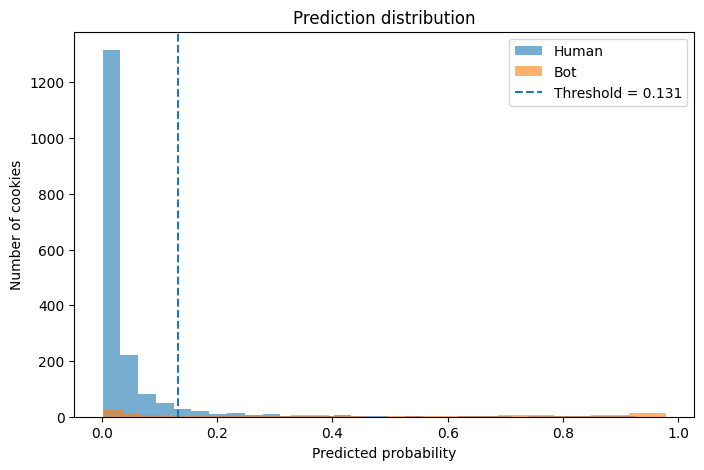

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.hist(
    analysis.loc[analysis['y_true'] == 0, 'y_pred'],
    bins=30,
    alpha=0.6,
    label='Human'
)

plt.hist(
    analysis.loc[analysis['y_true'] == 1, 'y_pred'],
    bins=30,
    alpha=0.6,
    label='Bot'
)

plt.axvline(
    threshold_70,
    linestyle='--',
    label=f'Threshold = {threshold_70:.3f}'
)

plt.xlabel('Predicted probability')
plt.ylabel('Number of cookies')
plt.title('Prediction distribution')
plt.legend()
plt.show()

Некоторые объекты модель классифицирует очень уверенно, а другие глубоко сидят в противоположном классе.

Однако есть и те, кто находятся прям рядом с порогом, т.е. линейно разделять в этом случае классы у модели не получается.

Есть боты, которые имеют похожее на людей поведение, а есть люди, поведение которых похоже на автоматизированных сборщиков.



---


Посмотрим Precision в диапазоне Recall 0.70–0.80, чтобы понять, насколько быстро падает Precision, когда мы пытаемся поймать больше ботов.

In [ ]:
recall_targets = [0.70, 0.72, 0.74, 0.76, 0.78, 0.80]

rows = []

for target_recall in recall_targets:

    valid = recall[:-1] >= target_recall

    if not valid.any():
        continue

    idx = np.where(valid)[0][-1]

    rows.append({
        'target_recall': target_recall,
        'actual_recall': recall[idx],
        'precision': precision[idx],
        'threshold': thresholds[idx]
    })

pd.DataFrame(rows)

,target_recall,actual_recall,precision,threshold
0,0.70,0.70000,0.491228,0.131277
1,0.72,0.72500,0.394558,0.090399
2,0.74,0.74375,0.343931,0.073482
3,0.76,0.76250,0.339833,0.069696
4,0.78,0.78125,0.318878,0.058854
5,0.80,0.80000,0.285714,0.050631


Посмотреть самые неуверенные объекты

In [ ]:
analysis['distance_to_threshold'] = (
    analysis['y_pred'] - threshold_70
).abs()

uncertain = analysis.sort_values('distance_to_threshold').head(30)

display(
    Xtr_ultim.loc[uncertain.index, feature_cols]
    .assign(
        y_true=uncertain['y_true'],
        prediction=uncertain['y_pred']
    )
)

,n_events,item_nunique,n_unique_events,n_unique_hours,is_active_night,is_active_morning,is_active_afternoon,is_active_evening,n_item_view,n_search_results_view,...,pointer_moves,platform_android,platform_ios,platform_desktop,transition_item_view_item_view,transition_item_view_search_results_view,transition_search_results_view_item_view,transition_search_results_view_search_results_view,y_true,prediction
10867,16,14,6,3,1,1,0,0,6,1,...,NaN,1,0,0,1.000000,0.000000,0.000000,0.000000,1,0.131277
10834,66,35,8,9,1,1,1,0,29,17,...,NaN,1,0,0,0.303030,0.303030,0.272727,0.121212,0,0.131622
9952,38,21,7,6,0,1,1,0,12,12,...,NaN,1,0,0,0.230769,0.307692,0.153846,0.307692,0,0.130553
9295,24,16,6,3,0,0,1,1,7,7,...,NaN,0,0,1,0.000000,0.500000,0.250000,0.250000,0,0.132250
9848,17,10,7,3,0,1,0,0,5,6,...,NaN,1,0,0,0.000000,0.333333,0.166667,0.500000,0,0.129616
10419,34,18,7,3,0,0,1,0,17,5,...,NaN,1,0,0,0.800000,0.000000,0.133333,0.066667,0,0.129322
9828,14,4,3,1,0,0,0,1,3,9,...,11.0,0,0,1,0.000000,0.300000,0.200000,0.500000,1,0.129161
10535,15,9,7,3,0,0,0,1,5,4,...,10.0,0,0,1,0.400000,0.400000,0.200000,0.000000,0,0.133411
9741,9,5,5,4,0,0,0,1,2,3,...,NaN,1,0,0,0.250000,0.250000,0.250000,0.250000,0,0.133681
10890,3,1,2,1,0,0,0,1,1,2,...,2.0,0,0,1,0.000000,0.000000,0.500000,0.500000,0,0.128872
